# GoingDeeper 04: Pose Estimation - Hourglass vs SimpleBaseline

In [2]:
# 필요한 라이브러리 import 및 프로젝트 경로 설정
import io, json, os, math, glob, pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# 프로젝트 내 각 폴더/파일 경로 설정
PROJECT_PATH = os.path.join(os.getenv("HOME"), 'work/AIFFEL_quest_rs/GoingDeeper/Dive04')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')  # ptrecords 파일 경로
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

# 모델 저장 폴더 생성
os.makedirs(MODEL_PATH, exist_ok=True)
print('경로 설정 완료')

경로 설정 완료


## 1. ptrecords 파일 확인
이전에 ray를 사용하여 이미지 + 어노테이션을 pickle로 직렬화한 `.ptrecords` 파일들을 확인합니다.  
train 64개, val 8개 shard로 분할되어 있어 병렬 로딩에 유리합니다.

In [10]:
# ptrecords 파일 목록 확인
train_records = sorted(glob.glob(os.path.join(PT_RECORD_PATH, 'train_*.ptrecords')))
val_records = sorted(glob.glob(os.path.join(PT_RECORD_PATH, 'val_*.ptrecords')))
print(f"Train shard 수: {len(train_records)}")
print(f"Val shard 수: {len(val_records)}")
print(f"예시: {train_records[0]}")

Train shard 수: 64
Val shard 수: 8
예시: /home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Dive04/ptrecords_mpii/train_0001_of_0064.ptrecords


## 2. PTRecordDataset 정의
`.ptrecords` 파일에서 미리 직렬화된 데이터를 읽는 Dataset입니다.  
매번 이미지 파일을 열지 않고, pickle로 저장된 바이트를 바로 읽으므로 I/O가 빠릅니다.

In [11]:
class PTRecordDataset(Dataset):
    """pickle로 직렬화된 .ptrecords 파일들에서 데이터를 읽는 Dataset"""
    def __init__(self, record_files, transform=None):
        self.transform = transform
        self.samples = []
        # 모든 shard 파일에서 샘플을 메모리로 로드
        for record_file in record_files:
            with open(record_file, 'rb') as f:
                while True:
                    try:
                        sample = pickle.load(f)
                        self.samples.append(sample)
                    except EOFError:
                        break
        print(f"총 {len(self.samples)}개 샘플 로드 완료")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        features = self.samples[idx]
        if self.transform:
            return self.transform(features)
        return features

print('PTRecordDataset 정의 완료')

PTRecordDataset 정의 완료


## 3. Preprocessor 정의
ptrecords에 저장된 데이터를 학습에 필요한 형태로 변환합니다.
1. JPEG 바이트 → 이미지 디코딩
2. 관절 좌표 기반 사람 영역 **crop**
3. 256x256으로 **resize** + [-1, 1] **정규화**
4. 64x64 크기의 **ground truth 히트맵** 생성 (16개 관절)

In [13]:
class Preprocessor(object):
    """ptrecords 데이터 전처리 및 히트맵 생성"""
    def __init__(self, image_shape=(256, 256, 3), heatmap_shape=(64, 64, 16), is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape      # (height, width, channels)
        self.heatmap_shape = heatmap_shape  # (height, width, num_heatmap)

    def __call__(self, features):
        # ptrecords에 저장된 JPEG 바이트에서 이미지 디코딩
        image = Image.open(io.BytesIO(features['image/encoded'])).convert('RGB')

        if self.is_train:
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, kp_x, kp_y = self.crop_roi(image, features, margin=random_margin)
        else:
            image, kp_x, kp_y = self.crop_roi(image, features)

        # 지정된 크기로 resize
        image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 이미지 정규화: [0,255] → [-1,1], (H,W,C) → (C,H,W)
        image_np = np.array(image).astype(np.float32) / 127.5 - 1.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        # ground truth 히트맵 생성
        heatmaps = self.make_heatmaps(features, kp_x, kp_y, self.heatmap_shape)
        return image_tensor, heatmaps

    def crop_roi(self, image, features, margin=0.2):
        """관절 좌표 기반 사람 영역 crop + 좌표 정규화(0~1)"""
        img_width, img_height = image.size
        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0

        # 유효한 keypoint만 사용
        masked_x = keypoint_x[keypoint_x > 0]
        masked_y = keypoint_y[keypoint_y > 0]
        extra = int(body_height * margin)

        xmin = max(int(masked_x.min().item()) - extra, 0)
        xmax = min(int(masked_x.max().item()) + extra, img_width)
        ymin = max(int(masked_y.min().item()) - extra, 0)
        ymax = min(int(masked_y.max().item()) + extra, img_height)

        cropped = image.crop((xmin, ymin, xmax, ymax))
        w, h = xmax - xmin, ymax - ymin

        norm_x = (keypoint_x.float() - xmin) / w
        norm_y = (keypoint_y.float() - ymin) / h
        return cropped, norm_x, norm_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        """하나의 관절에 대한 2D 가우시안 히트맵 생성"""
        heatmap = torch.zeros((height, width), dtype=torch.float32)
        xmin, ymin = x0 - 3*sigma, y0 - 3*sigma
        xmax, ymax = x0 + 3*sigma, y0 + 3*sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid, grid, indexing='xy')
        center = size // 2
        gaussian_patch = torch.exp(-((x_grid-center)**2 + (y_grid-center)**2) / (2*sigma**2)) * scale

        px0, py0 = max(0,-xmin), max(0,-ymin)
        px1, py1 = min(xmax,width)-xmin, min(ymax,height)-ymin
        hx0, hy0 = max(0,xmin), max(0,ymin)
        hx1, hy1 = min(xmax,width), min(ymax,height)
        heatmap[hy0:hy1, hx0:hx1] = gaussian_patch[int(py0):int(py1), int(px0):int(px1)]
        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        """16개 관절 전체에 대한 히트맵 생성 → (16, 64, 64)"""
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)

        heatmaps = []
        for i in range(heatmap_shape[2]):
            gaussian = self.generate_2d_guassian(
                heatmap_shape[0], heatmap_shape[1],
                int(y[i].item()), int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps.append(gaussian)
        return torch.stack(heatmaps, dim=0)

print('Preprocessor 정의 완료')

Preprocessor 정의 완료


## 4. 모델 정의 - Stacked Hourglass Network
- **BottleneckBlock**: Residual module (1x1→3x3→1x1 conv + skip connection)
- **HourglassModule**: 재귀적 encoder-decoder 구조 (모래시계 모양)
- **LinearLayer**: 1x1 conv + BN + ReLU
- **StackedHourglassNetwork**: Hourglass를 4개 쌓고, 각 stage마다 히트맵 출력 + intermediate supervision

In [15]:
class BottleneckBlock(nn.Module):
    """Residual Bottleneck Block: 1x1 → 3x3 → 1x1 conv + skip connection"""
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 채널 수가 다를 때 skip connection에 1x1 conv 적용
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)
        # Bottleneck: 채널 절반으로 줄이고 → 3x3 conv → 원래 채널로 복원
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, bias=False)

    def forward(self, x):
        identity = self.downsample_conv(x) if self.downsample else x
        out = self.relu(self.bn1(x))
        out = self.conv1(out)
        out = self.relu(self.bn2(out))
        out = self.conv2(out)
        out = self.relu(self.bn3(out))
        out = self.conv3(out)
        return out + identity


class HourglassModule(nn.Module):
    """재귀적 Hourglass 모듈: downsampling → 재귀 → upsampling + skip connection"""
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order
        # Up branch (skip connection 경로)
        self.up1_0 = BottleneckBlock(filters, filters)
        self.up1_blocks = nn.Sequential(*[BottleneckBlock(filters, filters) for _ in range(num_residual)])
        # Low branch (downsampling 경로)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[BottleneckBlock(filters, filters) for _ in range(num_residual)])
        # 재귀 or 최저 해상도 처리
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[BottleneckBlock(filters, filters) for _ in range(num_residual)])
        # Upsampling 전 후처리
        self.low3_blocks = nn.Sequential(*[BottleneckBlock(filters, filters) for _ in range(num_residual)])
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1_blocks(self.up1_0(x))                    # skip 경로
        low1 = self.low1_blocks(self.pool(x))                   # downsampling 경로
        low2 = self.low2(low1) if self.order > 1 else self.low2_blocks(low1)  # 재귀 or 최저
        low3 = self.low3_blocks(low2)
        return self.upsample(low3) + up1                        # upsampling + skip 합산


class LinearLayer(nn.Module):
    """1x1 Conv + BatchNorm + ReLU (feature 정리용)"""
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class StackedHourglassNetwork(nn.Module):
    """Hourglass를 num_stack개 쌓은 전체 네트워크"""
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        # 초기 feature 추출: 256x256x3 → 64x64x256
        self.conv1 = nn.Conv2d(input_shape[2], 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.bottleneck1 = BottleneckBlock(64, 128, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck2 = BottleneckBlock(128, 128)
        self.bottleneck3 = BottleneckBlock(128, 256, downsample=True)

        # 각 stack별 모듈 정의
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        self.intermediate_convs = nn.ModuleList()  # 중간 feature 변환
        self.intermediate_outs = nn.ModuleList()    # 중간 히트맵 변환

        for i in range(num_stack):
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            self.residual_modules.append(nn.Sequential(*[BottleneckBlock(256, 256) for _ in range(num_residual)]))
            self.linear_layers.append(LinearLayer(256, 256))
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1))
            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1))

    def forward(self, x):
        # 초기 feature 추출
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        # 각 hourglass stack 순차 실행
        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)
            # 마지막 stack이 아니면 다음 stack 입력에 피드백
            if i < self.num_stack - 1:
                x = self.intermediate_convs[i](lin) + self.intermediate_outs[i](heatmap)

        return outputs  # 각 stack의 히트맵 리스트

print('Hourglass 모델 정의 완료')

Hourglass 모델 정의 완료


## 5. Trainer 및 학습 함수 정의
- **Trainer**: 학습/검증 루프, loss 계산, lr 감소, 모델 저장 관리
- 관절 위치(labels > 0)에 81배 가중치를 적용하여 관절 부분을 더 중요하게 학습
- 출력은 epoch 단위 요약 + 100배치마다 진행 상황 표시

In [14]:
class Trainer(object):
    """모델 학습을 관리하는 클래스"""
    def __init__(self, model, epochs, global_batch_size, initial_learning_rate):
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10
        self.best_model = None
        self.train_losses = []  # epoch별 train loss 기록
        self.val_losses = []    # epoch별 val loss 기록

    def lr_decay(self):
        """val_loss 개선이 없으면 learning rate를 1/10으로 감소"""
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0
        self.patience_count += 1
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """관절 위치에 가중치를 적용한 MSE loss"""
        loss = 0
        for output in outputs:
            weights = (labels > 0).float() * 81 + 1  # 관절: 82, 배경: 1
            squared_error = (labels - output) ** 2
            loss += (squared_error * weights).mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images, labels = images.to(device), labels.to(device)
        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images, labels = images.to(device), labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """전체 학습 루프"""
        for epoch in range(1, self.epochs + 1):
            self.lr_decay()

            # --- Training ---
            total_train_loss, num_train = 0.0, 0
            for images, labels in train_loader:
                total_train_loss += self.train_step(images, labels, device)
                num_train += 1
                # 100 배치마다 진행 상황 출력
                if num_train % 100 == 0:
                    print(f"  [Train] batch {num_train} | avg_loss: {total_train_loss/num_train:.4f}")
            train_loss = total_train_loss / num_train

            # --- Validation ---
            total_val_loss, num_val = 0.0, 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                    num_val += 1
            val_loss = total_val_loss / num_val if num_val > 0 else float('nan')

            # loss 기록
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            # epoch 요약 출력
            print(f"Epoch {epoch}/{self.epochs} | lr: {self.current_learning_rate:.6f} | "
                  f"train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

            # 최저 val_loss 갱신 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"  -> Model saved: {model_name}")

print('Trainer 정의 완료')

Trainer 정의 완료


In [16]:
# 공통 설정값
IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)

def create_dataloader_from_ptrecords(record_files, batch_size, num_heatmap, is_train=True):
    """ptrecords 파일들로부터 DataLoader 생성 (빠른 데이터 로딩)"""
    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )
    dataset = PTRecordDataset(record_files, transform=preprocess)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=is_train,
        num_workers=4,       # 병렬 데이터 로딩
        pin_memory=True,     # GPU 전송 속도 향상
        drop_last=False,
        prefetch_factor=2
    )
    return dataloader

def train(model, epochs, learning_rate, num_heatmap, batch_size):
    """모델을 받아서 ptrecords 기반으로 학습"""
    # ptrecords shard 파일 목록
    train_records = sorted(glob.glob(os.path.join(PT_RECORD_PATH, 'train_*.ptrecords')))
    val_records = sorted(glob.glob(os.path.join(PT_RECORD_PATH, 'val_*.ptrecords')))

    train_loader = create_dataloader_from_ptrecords(train_records, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader_from_ptrecords(val_records, batch_size, num_heatmap, is_train=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(model, epochs, batch_size, initial_learning_rate=learning_rate)
    print(f"Start training on {device}...")
    best_model = trainer.run(train_loader, val_loader, device)
    return trainer, best_model

print('학습 함수 정의 완료')

학습 함수 정의 완료


## 6. Hourglass 모델 학습
4-stack Hourglass Network를 5 epoch 학습합니다.

In [17]:
%%time
# 하이퍼파라미터 설정
epochs = 5
batch_size = 16
num_heatmap = 16
learning_rate = 0.0007

# Hourglass 모델 생성 및 학습
hg_model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
hg_trainer, hg_best_model = train(hg_model, epochs, learning_rate, num_heatmap, batch_size)

총 22208개 샘플 로드 완료
총 2952개 샘플 로드 완료
Start training on cuda...
  [Train] batch 100 | avg_loss: 1.6679
  [Train] batch 200 | avg_loss: 1.5996
  [Train] batch 300 | avg_loss: 1.5593
  [Train] batch 400 | avg_loss: 1.5286
  [Train] batch 500 | avg_loss: 1.5047
  [Train] batch 600 | avg_loss: 1.4858
  [Train] batch 700 | avg_loss: 1.4686
  [Train] batch 800 | avg_loss: 1.4539
  [Train] batch 900 | avg_loss: 1.4394
  [Train] batch 1000 | avg_loss: 1.4273
  [Train] batch 1100 | avg_loss: 1.4176
  [Train] batch 1200 | avg_loss: 1.4077
  [Train] batch 1300 | avg_loss: 1.3986
Epoch 1/5 | lr: 0.000700 | train_loss: 1.3907 | val_loss: 1.2611
  -> Model saved: /home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Dive04/models/model-epoch-1-loss-1.2611.pt
  [Train] batch 100 | avg_loss: 1.2701
  [Train] batch 200 | avg_loss: 1.2636
  [Train] batch 300 | avg_loss: 1.2553
  [Train] batch 400 | avg_loss: 1.2530
  [Train] batch 500 | avg_loss: 1.2499
  [Train] batch 600 | avg_loss: 1.2487
  [Train] batch 700 | 

---
## 7. 모델 정의 - SimpleBaseline
ResNet50 backbone + Deconvolution head 3개 + 1x1 Conv로 구성된 단순한 구조

In [19]:
import torchvision.models as models

class SimpleBaseline(nn.Module):
    """
    Simple Baselines for Human Pose Estimation (Xiao et al., 2018)
    ResNet50 backbone + 3 deconv layers + 1x1 conv
    """
    def __init__(self, num_heatmap=16):
        super(SimpleBaseline, self).__init__()

        # ResNet50 backbone (pretrained on ImageNet)
        # 마지막 avgpool과 fc layer 제거
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        # ResNet50의 최종 출력 채널: 2048

        # Deconv head: 3개의 deconv layer로 해상도를 8배 복원
        # 각 layer: ConvTranspose2d(stride=2) + BatchNorm + ReLU
        self.deconv_layers = nn.Sequential(
            # 2048 → 256, 해상도 2배
            nn.ConvTranspose2d(2048, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # 256 → 256, 해상도 2배
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # 256 → 256, 해상도 2배
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # 최종 1x1 conv: 256채널 → num_heatmap(16)채널
        self.final_layer = nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        # backbone: (B, 3, 256, 256) → (B, 2048, 8, 8)
        x = self.backbone(x)
        # deconv: (B, 2048, 8, 8) → (B, 256, 64, 64)
        x = self.deconv_layers(x)
        # final: (B, 256, 64, 64) → (B, 16, 64, 64)
        x = self.final_layer(x)
        return [x]  # Hourglass와 동일한 리스트 형태로 반환 (Trainer 호환)

print('SimpleBaseline 모델 정의 완료')

SimpleBaseline 모델 정의 완료


In [20]:
%%time
# SimpleBaseline 모델 생성 및 학습 (동일한 하이퍼파라미터)
sb_model = SimpleBaseline(num_heatmap=num_heatmap)
sb_trainer, sb_best_model = train(sb_model, epochs, learning_rate, num_heatmap, batch_size)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s] 


총 22208개 샘플 로드 완료
총 2952개 샘플 로드 완료
Start training on cuda...
  [Train] batch 100 | avg_loss: 0.4016
  [Train] batch 200 | avg_loss: 0.3868
  [Train] batch 300 | avg_loss: 0.3772
  [Train] batch 400 | avg_loss: 0.3690
  [Train] batch 500 | avg_loss: 0.3630
  [Train] batch 600 | avg_loss: 0.3577
  [Train] batch 700 | avg_loss: 0.3533
  [Train] batch 800 | avg_loss: 0.3497
  [Train] batch 900 | avg_loss: 0.3464
  [Train] batch 1000 | avg_loss: 0.3435
  [Train] batch 1100 | avg_loss: 0.3408
  [Train] batch 1200 | avg_loss: 0.3387
  [Train] batch 1300 | avg_loss: 0.3367
Epoch 1/5 | lr: 0.000700 | train_loss: 0.3352 | val_loss: 0.3107
  -> Model saved: /home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Dive04/models/model-epoch-1-loss-0.3107.pt
  [Train] batch 100 | avg_loss: 0.3061
  [Train] batch 200 | avg_loss: 0.3070
  [Train] batch 300 | avg_loss: 0.3065
  [Train] batch 400 | avg_loss: 0.3052
  [Train] batch 500 | avg_loss: 0.3046
  [Train] batch 600 | avg_loss: 0.3042
  [Train] batch 700 | 

---
## 결과 비교

## STEP 1: Loss Curve

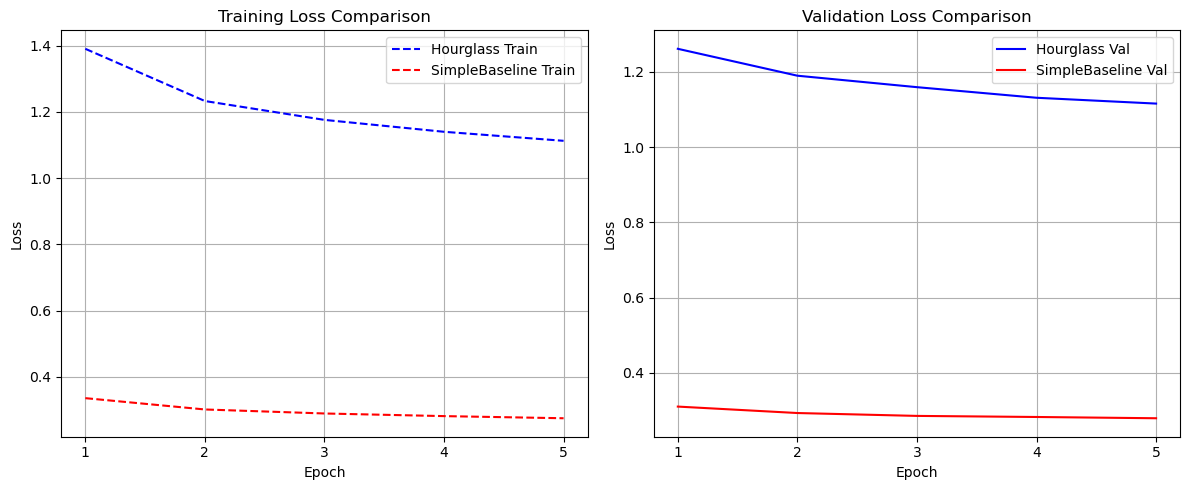

In [24]:
# 학습 진행 경과 시각화
import matplotlib.pyplot as plt

def plot_loss_comparison(hg_trainer, sb_trainer):
    plt.figure(figsize=(12, 5))
    
    # 1부터 시작하는 epoch 리스트 생성
    epochs = range(1, len(hg_trainer.train_losses) + 1)

    # Train Loss 비교
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hg_trainer.train_losses, label='Hourglass Train', color='blue', linestyle='--')
    plt.plot(epochs, sb_trainer.train_losses, label='SimpleBaseline Train', color='red', linestyle='--')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(epochs) # x축 눈금을 1, 2, 3, 4, 5로 고정
    plt.legend()
    plt.grid(True)

    # Validation Loss 비교
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hg_trainer.val_losses, label='Hourglass Val', color='blue')
    plt.plot(epochs, sb_trainer.val_losses, label='SimpleBaseline Val', color='red')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(epochs) # x축 눈금을 1, 2, 3, 4, 5로 고정
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 그래프 출력
plot_loss_comparison(hg_trainer, sb_trainer)

## STEP 2: 정성적 평가

In [27]:
def get_keypoints_from_heatmap(heatmaps):
    """히트맵에서 최대값 위치를 찾아 좌표로 변환 (B, 16, 64, 64) -> (B, 16, 2)"""
    B, C, H, W = heatmaps.shape
    heatmaps_flat = heatmaps.view(B, C, -1)
    max_idx = torch.argmax(heatmaps_flat, dim=2)
    preds_x = (max_idx % W).float()
    preds_y = (max_idx // W).float()
    return torch.stack([preds_x, preds_y], dim=2)

def visualize_detailed_comparison(model_hg, model_sb, dataloader, device, num_samples=3):
    model_hg.eval()
    model_sb.eval()
    
    # 데이터셋에서 샘플 추출 (이미지와 정답 레이블 모두 가져옴)
    images, labels = next(iter(dataloader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples].to(device)
    
    with torch.no_grad():
        # Hourglass: 마지막 stack 출력 사용
        out_hg = model_hg(images)[-1]
        # SimpleBaseline: 리스트의 첫 번째 요소 사용
        out_sb = model_sb(images)[0]
    
    # 각 결과에서 좌표(Point) 추출
    preds_gt = get_keypoints_from_heatmap(labels)   # Ground Truth
    preds_hg = get_keypoints_from_heatmap(out_hg)   # Hourglass 예측
    preds_sb = get_keypoints_from_heatmap(out_sb)   # SimpleBaseline 예측
    
    # 시각화 설정 (4개 컬럼: Original, GT, Hourglass, SimpleBaseline)
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    
    for i in range(num_samples):
        # 이미지 역정규화 (C, H, W -> H, W, C)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = (img + 1.0) * 127.5
        img = img.astype(np.uint8)
        
        # 1. Original Image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Sample {i+1}: Original")
        axes[i, 0].axis('off')
        
        # 2. Ground Truth (초록색 점)
        axes[i, 1].imshow(img)
        axes[i, 1].scatter(preds_gt[i, :, 0].cpu() * 4, preds_gt[i, :, 1].cpu() * 4, s=30, c='lime', label='GT')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')
        
        # 3. Stacked Hourglass (하늘색 X)
        axes[i, 2].imshow(img)
        axes[i, 2].scatter(preds_hg[i, :, 0].cpu() * 4, preds_hg[i, :, 1].cpu() * 4, s=30, c='cyan', marker='x')
        axes[i, 2].set_title("Stacked Hourglass")
        axes[i, 2].axis('off')
        
        # 4. SimpleBaseline (분홍색 +)
        axes[i, 3].imshow(img)
        axes[i, 3].scatter(preds_sb[i, :, 0].cpu() * 4, preds_sb[i, :, 1].cpu() * 4, s=30, c='magenta', marker='+')
        axes[i, 3].set_title("SimpleBaseline")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

총 2952개 샘플 로드 완료


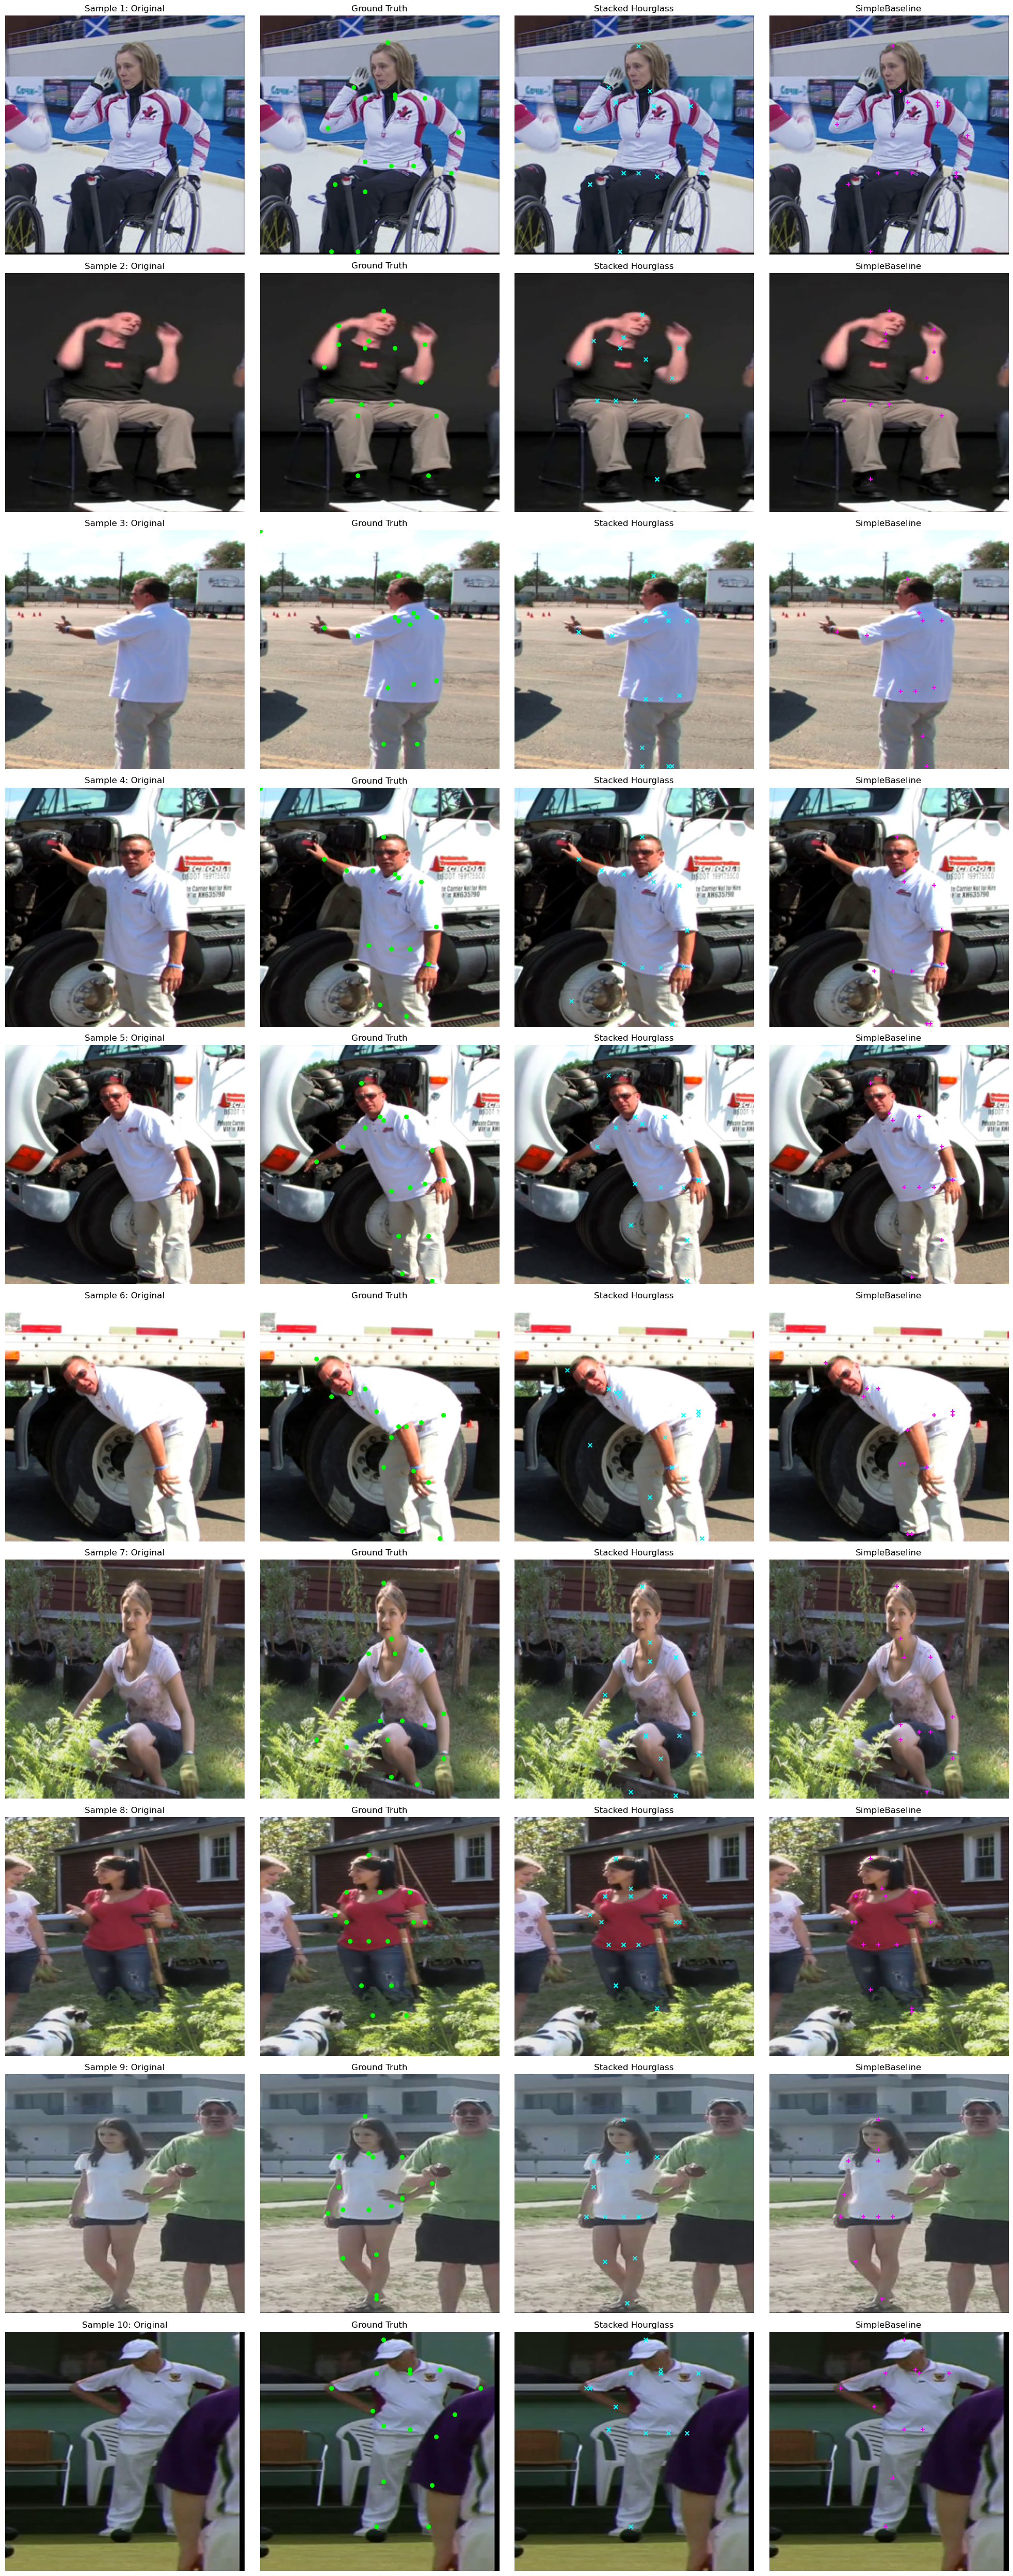

In [29]:
# 모델 가중치 로드 (최고 성능 모델 경로 사용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hg_model.load_state_dict(torch.load(hg_best_model))
sb_model.load_state_dict(torch.load(sb_best_model))

# Validation DataLoader 생성 (테스트용)
val_loader = create_dataloader_from_ptrecords(val_records, batch_size=10, num_heatmap=16, is_train=False)

# 시각화 실행
visualize_detailed_comparison(hg_model, sb_model, val_loader, device, num_samples=10)

## STEP 3: 정량적 평가 (PCKh@0.5) 계산

In [30]:
def calculate_pckh_score(preds, gts, head_idx=(8, 9), threshold_ratio=0.5):
    """
    PCKh@0.5 지표 계산 함수
    - head_idx: (Neck index, Head Top index) -> MPII 기준 8, 9번
    """
    batch_size = preds.shape[0]
    num_joints = preds.shape[1]
    
    # 1. 머리 크기(Head Segment Length) 계산
    # preds, gts shape: (B, 16, 2)
    head_dist = torch.sqrt(torch.sum((gts[:, head_idx[1], :] - gts[:, head_idx[0], :]) ** 2, dim=1))
    threshold = head_dist * threshold_ratio  # 머리 크기의 50%
    
    # 2. 모든 관절에 대해 거리 계산
    # distances shape: (B, 16)
    distances = torch.sqrt(torch.sum((preds - gts) ** 2, dim=2))
    
    # 3. 임계값보다 작은(정답인) 관절 개수 파악
    # threshold를 batch 크기에 맞게 확장 (B,) -> (B, 16)
    correct = distances < threshold.unsqueeze(1)
    
    return torch.sum(correct).item(), batch_size * num_joints

def evaluate_pckh(model, dataloader, device):
    model.eval()
    total_correct = 0
    total_joints = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            # Hourglass는 마지막 stack, SimpleBaseline은 첫 번째 출력
            output = outputs[-1] if isinstance(model, StackedHourglassNetwork) else outputs[0]
            
            preds = get_keypoints_from_heatmap(output)
            gts = get_keypoints_from_heatmap(labels)
            
            correct, joints = calculate_pckh_score(preds, gts)
            total_correct += correct
            total_joints += joints
            
    return (total_correct / total_joints) * 100

# --- 실행 및 결과 출력 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 가중치 로드 확인
hg_model.load_state_dict(torch.load(hg_best_model))
sb_model.load_state_dict(torch.load(sb_best_model))

print("Calculating PCKh@0.5...")
hg_pckh = evaluate_pckh(hg_model, val_loader, device)
sb_pckh = evaluate_pckh(sb_model, val_loader, device)

print(f"\n[Final Results]")
print(f"- Stacked Hourglass PCKh@0.5: {hg_pckh:.2f}%")
print(f"- SimpleBaseline    PCKh@0.5: {sb_pckh:.2f}%")

Calculating PCKh@0.5...

[Final Results]
- Stacked Hourglass PCKh@0.5: 67.79%
- SimpleBaseline    PCKh@0.5: 59.74%


# 결과 비교 분석

## 1. 정량적 평가 결과 (Quantitative Analysis)

| 지표 (Metric) | Stacked Hourglass (4-stack) | SimpleBaseline (ResNet50) |
| :--- | :---: | :---: |
| **PCKh @0.5** | **67.79%** | 59.74% |
| **최종 검증 손실 (Val Loss)** | 1.1156 | **0.2797** |
| **학습 소요 시간** | **약 1시간 18분** | **약 35분** |

* **정확도:** PCKh@0.5 지표 기준, **Stacked Hourglass**가 SimpleBaseline 대비 약 **8.05%p 높은 수치**를 보였다.
* **학습 효율성:** **SimpleBaseline**은 Hourglass 대비 **약 2.2배 빠른 학습 속도**와 압도적으로 낮은 Loss 수치를 보여주며 높은 수렴 안정성을 보였다.

---

## 2. 정성적 결과 분석 (Qualitative Analysis)

* **관절 추적 성능:** 두 모델 모두 전반적인 인체의 포즈와 주요 관절 위치를 양호하게 파악했다.
* **디테일 차이:** 손목, 발목 등 말단 관절의 경우 Hourglass가 Ground Truth(정답)에 더 밀착된 예측 결과를 보였다.
* **구조적 안정성:** SimpleBaseline은 일부 가려진 부위에서 불안정한 모습을 보였으나, Hourglass는 상대적으로 안정적인 것 같다.

---

## 3. 종합 분석 및 회고

### 3.1 Loss와 PCKh의 역전 현상
SimpleBaseline의 Loss가 훨씬 낮음에도 실제 정확도(PCKh)에서 Hourglass가 앞선 이유는 모델 구조의 특성에 기인합니다.
* **Stacked Hourglass:** 4개 스택의 중간 손실이 합산되어 수치상 Loss는 높게 측정되지만, 각 단계를 거치며 좌표를 교정하는 과정이 최종 정확도 향상에 결정적인 역할을 하였습니다.
* **SimpleBaseline:** 사전 학습된(Pretrained) 백본 덕분에 수렴은 빠르나, 5 Epoch라는 짧은 학습 시간 내에 정밀한 좌표를 획득하기에는 '단일 추론' 구조의 한계가 존재함을 확인하였습니다.

### 3.2 프로젝트 회고
* **성과:** Pose Estimation의 주요 지표인 PCKh를 직접 구현하고, 모델별 아키텍처 특성이 실제 성능에 미치는 영향을 데이터로 검증하였습니다.
* **향후 과제:** 5 Epoch의 학습량으로는 모델의 최대 잠재력을 확인하기에 부족함이 있었습니다. 하이퍼 파라미터를 변경하거나 다른 원인을 한번 찾아봐야겠다.

---
## Ablation Study: Hourglass Stage별 PCKh 비교
논문에서 주장한 iterative refinement 효과를 검증
Stack이 진행될수록 이전 예측을 참고하여 정확도가 향상되는지 확인

=== Hourglass Stage별 PCKh@0.5 ===
  Stack 1: PCKh@0.5 = 56.33%
  Stack 2: PCKh@0.5 = 63.55%
  Stack 3: PCKh@0.5 = 67.22%
  Stack 4: PCKh@0.5 = 67.79%


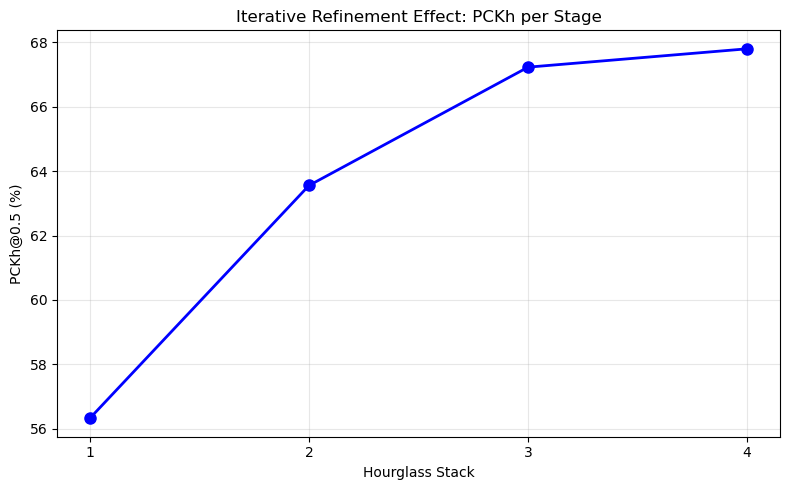

In [32]:
def evaluate_pckh_per_stage(model, dataloader, device):
    """Hourglass 각 stage별 PCKh 측정"""
    model.eval()
    num_stages = model.num_stack
    stage_correct = [0] * num_stages
    stage_total = [0] * num_stages

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            for stage_idx in range(num_stages):
                preds = get_keypoints_from_heatmap(outputs[stage_idx])
                gts = get_keypoints_from_heatmap(labels)
                correct, total = calculate_pckh_score(preds, gts)
                stage_correct[stage_idx] += correct
                stage_total[stage_idx] += total

    # 결과 출력
    print("=== Hourglass Stage별 PCKh@0.5 ===")
    stage_pckhs = []
    for i in range(num_stages):
        pckh = (stage_correct[i] / stage_total[i]) * 100
        stage_pckhs.append(pckh)
        print(f"  Stack {i+1}: PCKh@0.5 = {pckh:.2f}%")

    # 그래프
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_stages+1), stage_pckhs, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Hourglass Stack')
    plt.ylabel('PCKh@0.5 (%)')
    plt.title('Iterative Refinement Effect: PCKh per Stage')
    plt.xticks(range(1, num_stages+1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 실행
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hg_model.load_state_dict(torch.load(hg_best_model))
evaluate_pckh_per_stage(hg_model, val_loader, device)

## Ablation Study: Hourglass Stage별 PCKh 비교

| Stack | PCKh@0.5 | 이전 대비 개선 |
| :---: | :---: | :---: |
| Stack 1 | 56.33% | - |
| Stack 2 | 63.55% | +7.22%p |
| Stack 3 | 67.22% | +3.67%p |
| Stack 4 | 67.79% | +0.57%p |

Stack이 쌓일수록 정확도가 향상되며, 초반에 큰 폭으로 개선되고 후반에 수렴하는 패턴을 보입니다.  
Stack 1(56.33%)은 SimpleBaseline(59.74%)보다 낮지만, 반복 정제를 거치면서 역전합니다.